<a href="https://colab.research.google.com/github/Dhanushyapalaparvi/smart-energy-consumption-forecasting-using-anfis/blob/main/SoftComp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets

In [2]:
import opendatasets as od

od.download("https://www.kaggle.com/datasets/uciml/electric-power-consumption-data-set")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ysrisaidhanush
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/uciml/electric-power-consumption-data-set


100%|██████████| 19.4M/19.4M [00:00<00:00, 61.3MB/s]


In [3]:
import pandas as pd
path = './electric-power-consumption-data-set/household_power_consumption.txt'


In [4]:
df = pd.read_csv(path,sep = ';',
                 parse_dates = {'dt': ['Date','Time']},
                 infer_datetime_format=True,
                 low_memory=False,
                 na_values = ['?'],
                 index_col ='dt'
                 )

/tmp/ipykernel_4095/3122458557.py:1: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(path,sep = ';',
/tmp/ipykernel_4095/3122458557.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(path,sep = ';',
/tmp/ipykernel_4095/3122458557.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(path,sep = ';',


In [5]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dt,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [6]:
# filling missing values using interpolation
df = df.astype('float32')
df.interpolate(method = 'linear')

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dt,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.839996,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.630005,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.289993,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.740005,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.679993,15.8,0.0,1.0,17.0
...,...,...,...,...,...,...,...
2010-11-26 20:58:00,0.946,0.000,240.429993,4.0,0.0,0.0,0.0
2010-11-26 20:59:00,0.944,0.000,240.000000,4.0,0.0,0.0,0.0
2010-11-26 21:00:00,0.938,0.000,239.820007,3.8,0.0,0.0,0.0


In [7]:
# the current power consumption is minute we'll convert it into hourly
df_hourly = df.resample('h').mean()
df_hourly.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dt,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643875,18.099998,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580154,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232498,14.503333,0.0,1.433333,16.683332
2006-12-16 20:00:00,3.268567,0.075100,234.071503,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158661,13.046666,0.0,0.416667,17.216667


In [8]:
from sklearn.preprocessing import MinMaxScaler
# feature extraction
df_hourly['hour'] = df_hourly.index.hour
df_hourly['day_of_week'] = df_hourly.index.dayofweek
df_hourly['month'] = df_hourly.index.month
df_hourly['is_weekend'] = df_hourly['day_of_week'].apply(lambda x: 1 if x>=5 else 0)

In [9]:
scaler = MinMaxScaler(feature_range = (0,1))
df_hourly['scaled_power'] = scaler.fit_transform(df_hourly[['Global_active_power']])

Data prepation for training

In [10]:
import numpy as np

In [11]:
def create_anfis_dataset(df,n_lags=3):
  X,y = [],[]
  for i in range(len(df)-n_lags):
    lags = df['scaled_power'].iloc[i:i+n_lags].values
    hour_norm = df['hour'].iloc[i+n_lags]/23.0
    weekend = df['is_weekend'].iloc[i+n_lags]
    combined_input = np.append(lags,[hour_norm,weekend])
    X.append(combined_input)
    y.append(df['scaled_power'].iloc[i+n_lags])
  return np.array(X),np.array(y)
X,y = create_anfis_dataset(df_hourly)

splitting data as train and test data

In [12]:
split_idx = int(len(X)*0.8)
X_train,X_test = X[:split_idx],X[split_idx:]
y_train,y_test= y[:split_idx],y[split_idx:]
print(f"total samples: {len(X)}")
print(f"training shape: {X_train.shape}")
print(f"testing shape: {X_test.shape}")

total samples: 34586
training shape: (27668, 5)
testing shape: (6918, 5)


In [13]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

visualizing daily energy profile

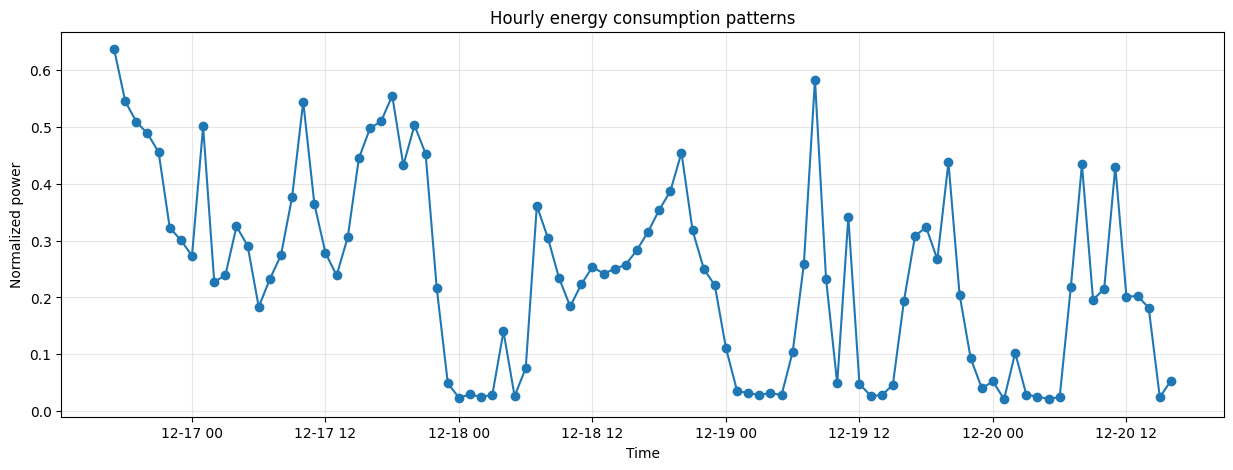

In [14]:
plt.figure(figsize=(15,5))
plt.plot(df_hourly['scaled_power'][:96],marker = 'o',linestyle = '-',color = 'tab:blue')
plt.title("Hourly energy consumption patterns")
plt.xlabel('Time')
plt.ylabel('Normalized power')
plt.grid(True,alpha = 0.3)
plt.show()

Checking and visualizing autocorrelation

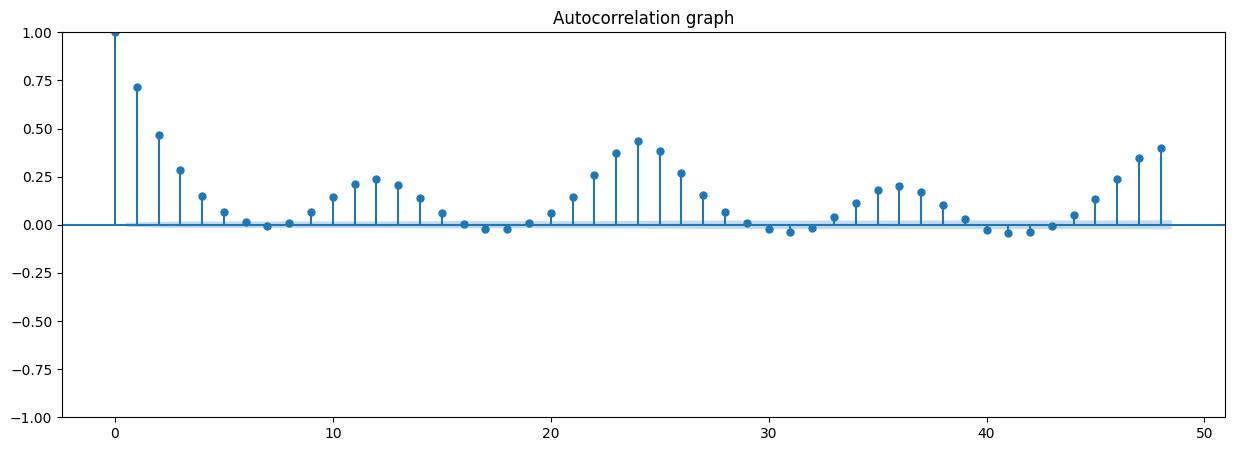

In [15]:
power_values = df_hourly['Global_active_power'].dropna().values
plt.figure(figsize=(15,5))
plot_acf(power_values,lags = 48,ax = plt.gca())
plt.title("Autocorrelation graph")
plt.show()

In [16]:
import torch
import torch.nn as nn
class ANFIS_Layer1(nn.Module):
    def __init__(self, n_inputs, n_rules):
        super(ANFIS_Layer1, self).__init__()
        initial_centers = torch.linspace(0, 1, n_rules).repeat(n_inputs, 1)
        self.c = nn.Parameter(initial_centers)

        self.sigma = nn.Parameter(torch.ones(n_inputs, n_rules) * 1.0)

    def forward(self, x):
        x = x.unsqueeze(2)
        safe_sigma = torch.clamp(self.sigma, min=0.1)
        mu = torch.exp(-0.5 * torch.pow((x - self.c) / safe_sigma, 2))
        return mu



In [50]:
import torch.nn.functional as F

class ANFIS_Stable_Final(nn.Module):
    def __init__(self, n_inputs, n_rules):
        super(ANFIS_Stable_Final, self).__init__()
        self.c = nn.Parameter(torch.linspace(0.1, 0.9, n_rules).repeat(n_inputs, 1))
        self.sigma = nn.Parameter(torch.ones(n_inputs, n_rules) * 0.5)
        self.consequent = nn.Parameter(torch.randn(n_rules, n_inputs + 1) * 0.01)

    def forward(self, x):
        batch_size = x.shape[0]

        # Layer 1: Membership (Gaussian)
        x_ext = x.unsqueeze(2)
        mu = torch.exp(-0.5 * torch.pow((x_ext - self.c) / (self.sigma + 1e-6), 2))

        # Layer 2 & 3: Rule strengths using Softmax
        w = torch.mean(mu, dim=1)
        w_norm = F.softmax(w, dim=1)

        # Layer 4: Takagi-Sugeno
        x_with_bias = torch.cat([x, torch.ones(batch_size, 1, device=x.device)], dim=1)
        f = torch.matmul(x_with_bias, self.consequent.T)

        # Layer 5: Output
        return torch.sum(w_norm * f, dim=1)

model = ANFIS_Stable_Final(n_inputs=5, n_rules=25)
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.002)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)
criterion = nn.MSELoss()

In [51]:
loss = nn.MSELoss()

In [52]:

X_test_t = torch.tensor(X_test,dtype = torch.float32)
y_test_t = torch.tensor(y_test,dtype = torch.float32)

In [53]:
X_train_t = torch.nan_to_num(torch.tensor(X_train, dtype=torch.float32))
y_train_t = torch.nan_to_num(torch.tensor(y_train, dtype=torch.float32))

print("Starting Industrial-Strength Training...")
for epoch in range(300):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)

    if torch.isnan(loss):
        print(f"Broke at epoch {epoch}. This usually means weights exploded.")
        break

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 0.1)
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/300], Loss: {loss.item():.6f}')

Starting Industrial-Strength Training...
Epoch [10/300], Loss: 0.016254
Epoch [20/300], Loss: 0.014962
Epoch [30/300], Loss: 0.014326
Epoch [40/300], Loss: 0.013849
Epoch [50/300], Loss: 0.013456
Epoch [60/300], Loss: 0.013120
Epoch [70/300], Loss: 0.012829
Epoch [80/300], Loss: 0.012569
Epoch [90/300], Loss: 0.012333
Epoch [100/300], Loss: 0.012113
Epoch [110/300], Loss: 0.011908
Epoch [120/300], Loss: 0.011718
Epoch [130/300], Loss: 0.011538
Epoch [140/300], Loss: 0.011369
Epoch [150/300], Loss: 0.011209
Epoch [160/300], Loss: 0.011058
Epoch [170/300], Loss: 0.010915
Epoch [180/300], Loss: 0.010780
Epoch [190/300], Loss: 0.010653
Epoch [200/300], Loss: 0.010536
Epoch [210/300], Loss: 0.010427
Epoch [220/300], Loss: 0.010321
Epoch [230/300], Loss: 0.010223
Epoch [240/300], Loss: 0.010132
Epoch [250/300], Loss: 0.010048
Epoch [260/300], Loss: 0.009970
Epoch [270/300], Loss: 0.009895
Epoch [280/300], Loss: 0.009825
Epoch [290/300], Loss: 0.009759
Epoch [300/300], Loss: 0.009698


In [54]:
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test_t).numpy()

y_pred_actual = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_true_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

print("Predictions completed.")

Predictions completed.


1st results

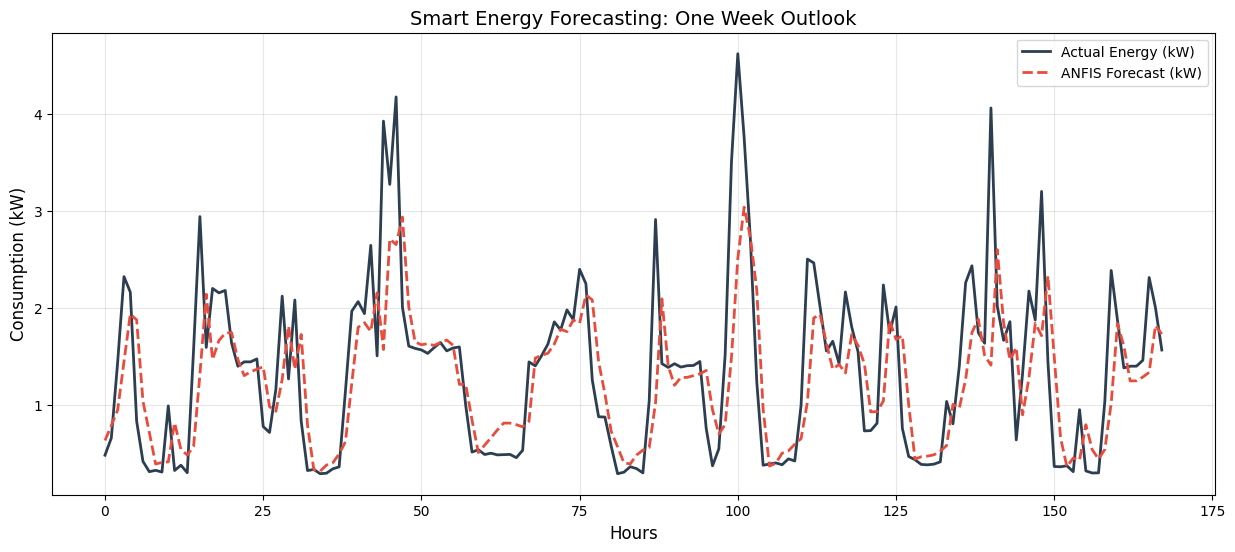

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
# Plotting a window of 168 hours (1 week)
plt.plot(y_true_actual[:168], label='Actual Energy (kW)', color='#2c3e50', linewidth=2)
plt.plot(y_pred_actual[:168], label='ANFIS Forecast (kW)', color='#e74c3c', linestyle='--', linewidth=2)

plt.title('Smart Energy Forecasting: One Week Outlook', fontsize=14)
plt.xlabel('Hours', fontsize=12)
plt.ylabel('Consumption (kW)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

results using scheduler and 500 epochs

In [56]:
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.005, weight_decay=1e-5)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

epochs = 500
print("Starting Intensive Training...")

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)

    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), 0.1)

    optimizer.step()
    scheduler.step()

    if (epoch + 1) % 50 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}, LR: {current_lr}')

print("Intensive Training Complete!")

Starting Intensive Training...
Epoch [50/500], Loss: 0.009319, LR: 0.005
Epoch [100/500], Loss: 0.009207, LR: 0.0025
Epoch [150/500], Loss: 0.009031, LR: 0.0025
Epoch [200/500], Loss: 0.008998, LR: 0.00125
Epoch [250/500], Loss: 0.008914, LR: 0.00125
Epoch [300/500], Loss: 0.008868, LR: 0.000625
Epoch [350/500], Loss: 0.008840, LR: 0.000625
Epoch [400/500], Loss: 0.008815, LR: 0.0003125
Epoch [450/500], Loss: 0.008798, LR: 0.0003125
Epoch [500/500], Loss: 0.008777, LR: 0.00015625
Intensive Training Complete!


In [57]:
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test_t).numpy()

y_pred_actual = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_true_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

y_pred_clean = np.nan_to_num(y_pred_actual, nan=np.nanmedian(y_pred_actual))
y_true_clean = np.nan_to_num(y_true_actual, nan=np.nanmedian(y_true_actual))

# Calculate Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))
mae = mean_absolute_error(y_true_clean, y_pred_clean)
mape = np.mean(np.abs((y_true_clean - y_pred_clean) / (y_true_clean + 1e-5))) * 100

print(f"--- FINAL MODEL PERFORMANCE ---")
print(f"RMSE: {rmse:.4f} kW")
print(f"MAE:  {mae:.4f} kW")
print(f"MAPE: {mape:.2f}%")

--- FINAL MODEL PERFORMANCE ---
RMSE: 0.5147 kW
MAE:  0.3732 kW
MAPE: 53.52%


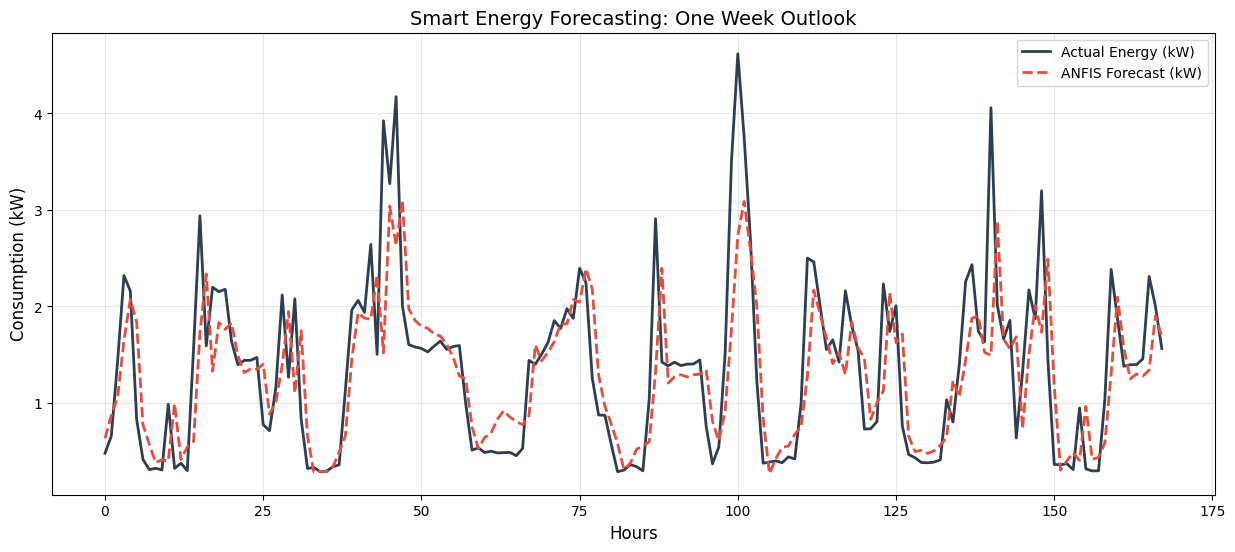

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
# Plotting a window of 168 hours (1 week)
plt.plot(y_true_actual[:168], label='Actual Energy (kW)', color='#2c3e50', linewidth=2)
plt.plot(y_pred_actual[:168], label='ANFIS Forecast (kW)', color='#e74c3c', linestyle='--', linewidth=2)

plt.title('Smart Energy Forecasting: One Week Outlook', fontsize=14)
plt.xlabel('Hours', fontsize=12)
plt.ylabel('Consumption (kW)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

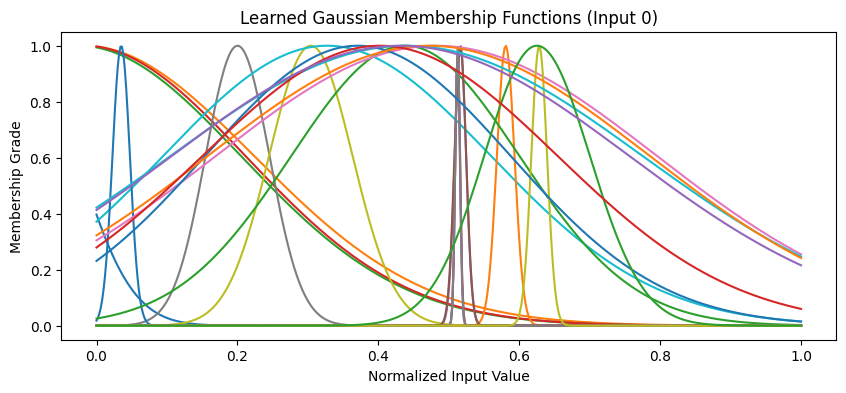

In [60]:
def plot_learned_mfs(model, input_idx=0):
    centers = model.c[input_idx].detach().numpy()
    sigmas = model.sigma[input_idx].detach().numpy()

    x = np.linspace(0, 1, 500)
    plt.figure(figsize=(10, 4))
    for c, s in zip(centers, sigmas):
        y = np.exp(-0.5 * ((x - c) / s)**2)
        plt.plot(x, y)

    plt.title(f'Learned Gaussian Membership Functions (Input {input_idx})')
    plt.xlabel('Normalized Input Value')
    plt.ylabel('Membership Grade')
    plt.show()

plot_learned_mfs(model)

In [64]:
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test_t).numpy()

# Inverse transform
y_pred_actual = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_true_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Clean
y_pred_clean = np.nan_to_num(y_pred_actual, nan=np.nanmedian(y_pred_actual))
y_true_clean = np.nan_to_num(y_true_actual, nan=np.nanmedian(y_true_actual))

# WMAPE Calculation
wmape = np.sum(np.abs(y_true_clean - y_pred_clean)) / np.sum(y_true_clean) * 100
rmse = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))

print(f"--- POST-HUBER METRICS ---")
print(f"RMSE: {rmse:.4f} kW")
print(f"WMAPE: {wmape:.2f}%")

--- POST-HUBER METRICS ---
RMSE: 0.5085 kW
WMAPE: 35.88%
